# 5-mer context-corrected mutation rate -- original logic, log-rate fix

## The logic, step by step

1. **Per-nucleotide baseline rates** from rare SNPs mapped to random
   intergenic regions -- one rate each for A/T/C/G.
2. **5-mer background counts** from scanning the intergenic sequences --
   how often each of the 1024 contexts occurs.
3. **Change value** per 5-mer: `c_k = r_k / r_base[centre_base(k)]`, where
   `r_k = -ln(1-p_k)` (was `p_k/(1-p_k)`) and `r_base` is that context's own
   centre nucleotide's baseline, also on the same `-ln(1-p)` scale (was
   odds).
4. **Same procedure applied to each region's rare SNPs** (TSS, lncRNA TSS,
   ...): mutations assigned to feature-relative positions, building a
   1024 x N_positions count matrix per region.
5. **Context-corrected rate**: each count weighted by its `Change` value,
   summed, divided by the raw count total at that position -- exactly
   `Rate = Change/Count` from your original notebook, and the final output
   of this notebook.

## Outputs

| File | Contents |
|---|---|
| `config.json`, `context_lib.py` | as before |
| `qc_extraction_report.txt` | intergenic + every region |
| `intergenic_master_rates.csv` | per-5-mer `p_k`, `r_k` |
| `{region}_observed_counts.tsv` | `N[k,p]` -- 1024 x N_positions |
| `{region}_rates_{mode}.tsv` | `Position`, `Raw_Count`, `Change_weighted_rate` |
| `{region}_rate.png` | one figure per region, both modes |

## 0. Configuration

No reference-window FASTA needed for this version -- only the mapped-SNP
files (intergenic + one per region). `reference_fasta` is still needed
because extracting the 5-mer *at each SNP site* still requires pulling
sequence around each variant.

In [1]:
import json, os

WORKDIR = "/media/alexpalazzo1/ohta/Tina/TSS_hypermutation/Rare_SNP/Context_corrections"

CONFIG = {
    "workdir": WORKDIR,

    "reference_fasta":  "/media/alexpalazzo1/ohta/Tina/SNPs_and_Indels/PrimateSNPs/Homo_sapiens.GRCh38.dna.toplevel.fa",
    "intergenic_fasta": "/media/alexpalazzo1/ohta/Tina/SNPs_and_Indels/PrimateSNPs/human_intergenic_random_1kb.fa",
    "intergenic_snps":  "/media/alexpalazzo1/ohta/Tina/TSS_hypermutation/Rare_SNP/rareSNP_mapped_random_intergenic_rare.txt",

    # SNP file column layout (0-based) -- shared by intergenic and all regions
    "col_relpos":   0,
    "col_mutation": 1,
    "col_chrom":   -2,
    "col_pos":     -1,
    "col_strand":  None,

    # Default window geometry -- override per-region below if a region differs
    "n_positions": 1001,   # offsets 0 .. 1000
    "tss_anchor":  500,    # offset of the feature anchor itself

    "bedtools":        "bedtools",
    "force_reextract": False,
    
    "regions": {
        "lncRNA": {
            "snps":  "/media/alexpalazzo1/ohta/Tina/TSS_hypermutation/Rare_SNP/rareSNP_mapped_FANTOM_CAT_Testis_lncRNA_hg38.txt",
        },
        "lncRNA_noexpress": {
            "snps":  "/media/alexpalazzo1/ohta/Tina/TSS_hypermutation/Rare_SNP/lncRNA/results/rareSNP_mapped_lncrna_non_testis.txt",
            "col_chrom": -3, "col_pos": -2, "col_strand": -1,
        },
        "noexpress": {
            "snps":  "/media/alexpalazzo1/ohta/Tina/TSS_hypermutation/Rare_SNP/rareSNP_mapped_TSS_rare_tpm0_noCAGE.txt",
        },
        "RNAPII": {
            "snps":  "/media/alexpalazzo1/ohta/Tina/TSS_hypermutation/Rare_SNP/RNAPII/rareSNP_mapped_RNAPII_human_testes_thresholded_intergenic.txt",
            "col_chrom": -3, "col_pos": -2, "col_strand": -1,
        },
    },

    "modes": {
        "nonCpG":       {"exclude_cpg": True,  "color": "#0C8BBC"},
        "allContexts":  {"exclude_cpg": False, "color": "#CC5471"},
    },
}

os.makedirs(WORKDIR, exist_ok=True)
with open(os.path.join(WORKDIR, "config.json"), "w") as f:
    json.dump(CONFIG, f, indent=2)

print(f"Config written to {WORKDIR}/config.json")
for k in ["intergenic_fasta", "intergenic_snps", "reference_fasta"]:
    p = CONFIG[k]
    print(f"  {'OK ' if os.path.exists(p) else 'MISSING'}  {k}: {p}")
for name, spec in CONFIG["regions"].items():
    p = spec["snps"]
    print(f"  region [{name}]  {'OK ' if os.path.exists(p) else 'MISSING'}  snps: {p}")

Config written to /media/alexpalazzo1/ohta/Tina/TSS_hypermutation/Rare_SNP/Context_corrections/config.json
  OK   intergenic_fasta: /media/alexpalazzo1/ohta/Tina/SNPs_and_Indels/PrimateSNPs/human_intergenic_random_1kb.fa
  OK   intergenic_snps: /media/alexpalazzo1/ohta/Tina/TSS_hypermutation/Rare_SNP/rareSNP_mapped_random_intergenic_rare.txt
  OK   reference_fasta: /media/alexpalazzo1/ohta/Tina/SNPs_and_Indels/PrimateSNPs/Homo_sapiens.GRCh38.dna.toplevel.fa
  region [lncRNA]  OK   snps: /media/alexpalazzo1/ohta/Tina/TSS_hypermutation/Rare_SNP/rareSNP_mapped_FANTOM_CAT_Testis_lncRNA_hg38.txt
  region [lncRNA_noexpress]  OK   snps: /media/alexpalazzo1/ohta/Tina/TSS_hypermutation/Rare_SNP/lncRNA/results/rareSNP_mapped_lncrna_non_testis.txt
  region [noexpress]  OK   snps: /media/alexpalazzo1/ohta/Tina/TSS_hypermutation/Rare_SNP/rareSNP_mapped_TSS_rare_tpm0_noCAGE.txt
  region [RNAPII]  OK   snps: /media/alexpalazzo1/ohta/Tina/TSS_hypermutation/Rare_SNP/RNAPII/rareSNP_mapped_RNAPII_human_t

## 1. Shared library

In [2]:
import json, os

CFG = json.load(open("/media/alexpalazzo1/ohta/Tina/TSS_hypermutation/Rare_SNP/Context_corrections/config.json"))

LIB = r"""
import os, math, csv, subprocess
from collections import defaultdict
from itertools import product
import numpy as np

BASES = "ACGT"
ALL_5MERS = [''.join(c) for c in product(BASES, repeat=5)]
KMER_IDX  = {k: i for i, k in enumerate(ALL_5MERS)}
CENTRE_BASE = np.array([k[2] for k in ALL_5MERS])


def is_cpg_context(k):
    \"\"\"True if the centre base of the 5-mer belongs to a CpG dinucleotide.\"\"\"
    return (k[2] == 'C' and k[3] == 'G') or (k[2] == 'G' and k[1] == 'C')


CPG_MASK = np.array([is_cpg_context(k) for k in ALL_5MERS])


def rate_from_p(p):
    \"\"\"Saturation-corrected per-site rate r = -ln(1-p). NaN if p not in [0,1).\"\"\"
    if not (0.0 <= p < 1.0):
        return float('nan')
    return -math.log(1.0 - p)


def read_fasta(path):
    name, chunks = None, []
    with open(path) as f:
        for line in f:
            line = line.rstrip()
            if not line:
                continue
            if line[0] == '>':
                if name is not None:
                    yield name, ''.join(chunks)
                name, chunks = line[1:], []
            else:
                chunks.append(line.upper())
    if name is not None:
        yield name, ''.join(chunks)


def iter_snp_rows(path, cfg):
    for ln, line in enumerate(open(path), 1):
        parts = line.split()
        if len(parts) < 3:
            continue
        try:
            rec = {
                'line': ln,
                'relpos': int(float(parts[cfg['col_relpos']])),
                'mutation': parts[cfg['col_mutation']],
                'chrom': parts[cfg['col_chrom']],
                'pos': int(float(parts[cfg['col_pos']])),
            }
        except (ValueError, IndexError):
            continue
        if cfg['col_strand'] is None:
            rec['strand'] = '+'
        else:
            s = parts[cfg['col_strand']]
            rec['strand'] = s if s in ('+', '-') else '+'
        yield rec


def write_5mer_bed(snp_file, bed_file, cfg):
    n = 0
    with open(bed_file, 'w') as out:
        for r in iter_snp_rows(snp_file, cfg):
            start = r['pos'] - 3
            end   = r['pos'] + 2
            if start < 0:
                continue
            out.write(f"{r['chrom']}\t{start}\t{end}\tsnp{n}\t0\t{r['strand']}\n")
            n += 1
    return n


def run_getfasta(reference, bed_file, out_fa, bedtools='bedtools', stranded=True):
    cmd = [bedtools, 'getfasta', '-fi', reference, '-bed', bed_file, '-fo', out_fa, '-name']
    if stranded:
        cmd.append('-s')
    res = subprocess.run(cmd, capture_output=True, text=True)
    if res.returncode != 0:
        raise RuntimeError(f"bedtools failed:\n{res.stderr}")
    return res.stderr.strip()


def merge_snp_with_fasta(snp_file, fa_file, out_file, cfg):
    seqs = [s for _, s in read_fasta(fa_file)]
    rows = list(iter_snp_rows(snp_file, cfg))
    if len(rows) != len(seqs):
        raise ValueError(f"record mismatch: {len(rows)} SNP rows vs {len(seqs)} FASTA records")
    qc = {'total': 0, 'centre_match': 0, 'centre_mismatch': 0,
          'centre_complement': 0, 'bad_seq': 0}
    comp = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C'}
    with open(out_file, 'w') as out:
        for r, seq in zip(rows, seqs):
            qc['total'] += 1
            seq = seq.upper()
            if len(seq) != 5 or any(b not in BASES for b in seq):
                qc['bad_seq'] += 1
            else:
                ref = r['mutation'][0] if len(r['mutation']) == 3 else None
                if ref in BASES:
                    if seq[2] == ref:
                        qc['centre_match'] += 1
                    elif seq[2] == comp.get(ref):
                        qc['centre_complement'] += 1
                    else:
                        qc['centre_mismatch'] += 1
            out.write(f"{r['relpos']}\t{r['mutation']}\t{r['chrom']}\t{r['pos']}\t{r['strand']}\t{seq}\n")
    return qc


def count_5mers_pooled(fasta_path):
    counts = np.zeros(len(ALL_5MERS), dtype=np.int64)
    for _, seq in read_fasta(fasta_path):
        for i in range(len(seq) - 4):
            j = KMER_IDX.get(seq[i:i + 5])
            if j is not None:
                counts[j] += 1
    return counts


def count_mutation_5mers(merged_file):
    counts = np.zeros(len(ALL_5MERS), dtype=np.int64)
    for line in open(merged_file):
        parts = line.split()
        if len(parts) < 6:
            continue
        j = KMER_IDX.get(parts[-1])
        if j is not None:
            counts[j] += 1
    return counts


def observed_matrix(merged_file, n_positions):
    N = np.zeros((len(ALL_5MERS), n_positions), dtype=np.int64)
    dropped = 0
    for line in open(merged_file):
        parts = line.split()
        if len(parts) < 6:
            continue
        j = KMER_IDX.get(parts[-1])
        try:
            p = int(parts[0])
        except ValueError:
            continue
        if j is None or not (0 <= p < n_positions):
            dropped += 1
            continue
        N[j, p] += 1
    return N, dropped


def build_context_mask(exclude_cpg, valid):
    m = valid.copy()
    if exclude_cpg:
        m &= ~CPG_MASK
    return m


def per_nucleotide_baselines(bg, mut, mask):
    \"\"\"
    Pooled per-nucleotide rate: for each base X, pool mutation and background
    counts across every valid context centred on X, THEN transform:
        p_base[X] = sum_k mut_k / sum_k bg_k     (centre(k) == X, k in mask)
        r_base[X] = -ln(1 - p_base[X])
    Matches the original notebooks' BASE_MUTATION_RATES (a plain
    mutation/background ratio per nucleotide), just computed here from the
    already-built 5-mer tables instead of a separate base-counting pass, and
    with -ln(1-p) in place of the odds transform p/(1-p).
    \"\"\"
    r_base = {}
    for base in BASES:
        sel = mask & (CENTRE_BASE == base)
        if not sel.any() or bg[sel].sum() == 0:
            r_base[base] = float('nan')
            continue
        p_b = mut[sel].sum() / bg[sel].sum()
        r_base[base] = rate_from_p(p_b) if p_b < 1 else float('nan')
    return r_base


def pooled_overall_rate(bg, mut, mask):
    \"\"\"Single overall intergenic mutation rate (probability), pooled across
    every valid context in this mode -- the 'intergenic base mutation rate'
    your original notebook multiplied the final context-corrected ratio by.
    \"\"\"
    return float(mut[mask].sum() / bg[mask].sum())


def compute_change_values(r, bg, mut, mask):
    \"\"\"c_k = r_k / r_base[centre_base(k)] for every context in mask.\"\"\"
    r_base = per_nucleotide_baselines(bg, mut, mask)
    cb = CENTRE_BASE[mask]
    denom = np.array([r_base[b] for b in cb])
    return r[mask] / denom, r_base


def compute_legacy_rate(N, c, mask):
    \"\"\"
    Change_weighted_rate(p) = sum_k N[k,p] * c[k] / sum_k N[k,p]
        -- your original context-corrected rate: each observed mutation
        count weighted by its context's Change value, normalised by the
        raw count total at that position. This is exactly "Rate =
        Change/Count" from your original notebook -- no further scaling.
    \"\"\"
    Nm, cm = N[mask], c
    nsum = Nm.sum(axis=0).astype(float)
    with np.errstate(divide='ignore', invalid='ignore'):
        change_weighted = np.where(nsum > 0, (cm @ Nm) / nsum, np.nan)
    return {'Raw_Count': nsum, 'Change_weighted_rate': change_weighted,
            'n_contexts': int(mask.sum())}
"""

lib_path = os.path.join(CFG["workdir"], "context_lib.py")
with open(lib_path, "w") as f:
    f.write(LIB.replace('\\"\\"\\"', '"""'))

import importlib, sys
sys.path.insert(0, CFG["workdir"])
import context_lib; importlib.reload(context_lib)
print(f"Wrote {lib_path}  ({len(context_lib.ALL_5MERS)} contexts, "
      f"{int(context_lib.CPG_MASK.sum())} CpG-centred)")

Wrote /media/alexpalazzo1/ohta/Tina/TSS_hypermutation/Rare_SNP/Context_corrections/context_lib.py  (1024 contexts, 128 CpG-centred)


## 2. Extract 5-mers at SNP sites, with strand QC -- intergenic + every region

Loops over `intergenic` plus every entry in `CONFIG["regions"]`. Six-column
BED, `subprocess`-driven extraction, centre-base QC check -- same as before.

**Read the QC report before continuing**, for every region.

In [3]:
import json, os, sys, importlib

CFG = json.load(open("/media/alexpalazzo1/ohta/Tina/TSS_hypermutation/Rare_SNP/Context_corrections/config.json"))
sys.path.insert(0, CFG["workdir"]); import context_lib as cl; importlib.reload(cl)
W = CFG["workdir"]

COL_KEYS = ["col_relpos", "col_mutation", "col_chrom", "col_pos", "col_strand"]

def effective_cfg(spec):
    """Column layout can differ between sources (e.g. an extra trailing
    strand column). Start from the global defaults, then let a region's own
    col_* entries (if any) override just those keys."""
    merged = dict(CFG)
    for k in COL_KEYS:
        if k in spec:
            merged[k] = spec[k]
    return merged

sources = {"intergenic": ({"snps": CFG["intergenic_snps"]})}
sources.update(CFG["regions"])

def extract(tag, snp_file, cfg):
    bed    = os.path.join(W, f"{tag}_5mer.bed")
    fa     = os.path.join(W, f"{tag}_5mer.fa")
    merged = os.path.join(W, f"{tag}_5mer_merged.txt")
    if CFG["force_reextract"] or not os.path.exists(merged):
        n = cl.write_5mer_bed(snp_file, bed, cfg)
        cl.run_getfasta(CFG["reference_fasta"], bed, fa,
                        bedtools=CFG["bedtools"],
                        stranded=cfg["col_strand"] is not None)
        qc = cl.merge_snp_with_fasta(snp_file, fa, merged, cfg)
        qc['bed_records'] = n
    else:
        qc = None
        print(f"  {tag}: reusing existing {os.path.basename(merged)} "
              f"(set force_reextract=True to rebuild)")
    return merged, qc

def duplicate_positions(snp_file, cfg):
    seen, dup = set(), 0
    for r in cl.iter_snp_rows(snp_file, cfg):
        key = (r['chrom'], r['pos'])
        if key in seen:
            dup += 1
        else:
            seen.add(key)
    return dup, len(seen)

report = []
for tag, spec in sources.items():
    snp_file = spec["snps"]
    cfg = effective_cfg(spec)
    overrides = {k: cfg[k] for k in COL_KEYS if k in spec}
    print(f"Processing {tag} ..." + (f"  (column overrides: {overrides})" if overrides else ""))

    # quick pre-flight: does the first data line even have enough columns
    # for the configured indices? Catches a layout mismatch before wasting
    # time on bedtools.
    try:
        first = next(l for l in open(snp_file) if l.strip())
        nfields = len(first.split())
        needed = [cfg[k] for k in ["col_relpos", "col_chrom", "col_pos"]]
        bad_idx = [i for i in needed if i >= nfields or i < -nfields]
        if bad_idx:
            print(f"  !! configured column index {bad_idx} is out of range for a "
                  f"{nfields}-column file -- check col_chrom/col_pos/col_relpos for this source.")
    except (StopIteration, FileNotFoundError):
        pass

    merged, qc = extract(tag, snp_file, cfg)
    dup, uniq = duplicate_positions(snp_file, cfg)
    report.append(f"[{tag}]")
    report.append(f"  source: {snp_file}")
    if overrides:
        report.append(f"  column overrides: {overrides}")
    report.append(f"  unique genomic positions : {uniq:,}")
    report.append(f"  duplicated positions     : {dup:,}"
                  + ("   <-- multi-allelic sites inflate p; consider collapsing" if dup else ""))
    if qc:
        t = qc['total']
        if t == 0:
            report.append("  !! 0 SNP rows parsed from this source -- file is empty, "
                          "unreadable, or every line failed to parse "
                          "(check column layout / col_relpos / col_mutation / col_chrom / col_pos).")
        else:
            for k in ['centre_match', 'centre_complement', 'centre_mismatch', 'bad_seq']:
                report.append(f"  {k:<20}: {qc[k]:>12,}  ({100*qc[k]/t:6.2f}%)")
            if qc['centre_complement'] > 0.02 * t:
                report.append("  !! large complement fraction -> STRAND MISMATCH. Set col_strand and rerun.")
            if qc['centre_mismatch'] > 0.01 * t:
                report.append("  !! centre bases disagree with the recorded reference allele. "
                              "Check the coordinate convention (1-based assumed).")
    report.append("")

txt = "\n".join(report)
open(os.path.join(W, "qc_extraction_report.txt"), "w").write(txt)
print("\n" + txt)

Processing intergenic ...
  intergenic: reusing existing intergenic_5mer_merged.txt (set force_reextract=True to rebuild)
Processing lncRNA ...
Processing lncRNA_noexpress ...  (column overrides: {'col_chrom': -3, 'col_pos': -2, 'col_strand': -1})
Processing noexpress ...
Processing RNAPII ...  (column overrides: {'col_chrom': -3, 'col_pos': -2, 'col_strand': -1})

[intergenic]
  source: /media/alexpalazzo1/ohta/Tina/TSS_hypermutation/Rare_SNP/rareSNP_mapped_random_intergenic_rare.txt
  unique genomic positions : 2,251,475
  duplicated positions     : 166,018   <-- multi-allelic sites inflate p; consider collapsing

[lncRNA]
  source: /media/alexpalazzo1/ohta/Tina/TSS_hypermutation/Rare_SNP/rareSNP_mapped_FANTOM_CAT_Testis_lncRNA_hg38.txt
  unique genomic positions : 837,440
  duplicated positions     : 84,834   <-- multi-allelic sites inflate p; consider collapsing
  centre_match        :      922,274  (100.00%)
  centre_complement   :            0  (  0.00%)
  centre_mismatch     :  

## 3. Intergenic context rates

For each 5-mer *k*: $p_k = \text{mut}_k/\text{bg}_k$, $r_k = -\ln(1-p_k)$.
Contexts with $p_k \ge 1$ are dropped. Per-nucleotide baselines and the
pooled overall rate are computed per mode and printed.

In [4]:
import json, os, sys, importlib, csv
import numpy as np

CFG = json.load(open("/media/alexpalazzo1/ohta/Tina/TSS_hypermutation/Rare_SNP/Context_corrections/config.json"))
sys.path.insert(0, CFG["workdir"]); import context_lib as cl; importlib.reload(cl)
W = CFG["workdir"]

bg  = cl.count_5mers_pooled(CFG["intergenic_fasta"])
mut = cl.count_mutation_5mers(os.path.join(W, "intergenic_5mer_merged.txt"))

with np.errstate(divide='ignore', invalid='ignore'):
    p = np.where(bg > 0, mut / bg, np.nan)
r = np.array([cl.rate_from_p(v) if np.isfinite(v) else np.nan for v in p])
valid = np.isfinite(r) & (bg > 0)

rows, excluded = [], []
for i, k in enumerate(cl.ALL_5MERS):
    rec = {'Context': k, 'Centre_Base': k[2], 'Is_CpG': int(cl.CPG_MASK[i]),
           'Background_Count': int(bg[i]), 'Mutation_Count': int(mut[i]),
           'p': f"{p[i]:.8f}" if np.isfinite(p[i]) else "NA",
           'r_minus_log': f"{r[i]:.8f}" if np.isfinite(r[i]) else "NA"}
    (rows if valid[i] else excluded).append(rec)

def dump(recs, path):
    if not recs:
        open(path, 'w').write("Context,Reason\n")
        return
    keys = list(recs[0].keys())
    with open(path, 'w', newline='') as f:
        wr = csv.DictWriter(f, fieldnames=keys); wr.writeheader(); wr.writerows(recs)

dump(rows,     os.path.join(W, "intergenic_master_rates.csv"))
dump(excluded, os.path.join(W, "intergenic_master_rates_excluded.csv"))
np.savez(os.path.join(W, "intergenic_rates.npz"), bg=bg, mut=mut, p=p, r=r, valid=valid)

print(f"Usable contexts : {int(valid.sum())} / {len(cl.ALL_5MERS)}")
if excluded:
    print(f"Excluded (p>=1) : {len(excluded)}  -> {[e['Context'] for e in excluded]}")
print()
for mode in CFG["modes"]:
    m = cl.build_context_mask(CFG["modes"][mode]["exclude_cpg"], valid)
    r_base = cl.per_nucleotide_baselines(bg, mut, m)
    p_overall = cl.pooled_overall_rate(bg, mut, m)
    print(f"[{mode}] n={int(m.sum())} contexts   pooled overall rate = {p_overall:.6f}")
    for base in "ACGT":
        rb = r_base[base]
        print(f"    r_base[{base}] = {rb:.6f}   "
              f"(equivalent probability = {1-np.exp(-rb):.4f})" if np.isfinite(rb)
              else f"    r_base[{base}] = NA")

Usable contexts : 1021 / 1024
Excluded (p>=1) : 3  -> ['CCGGT', 'GCGCA', 'TCGCA']

[nonCpG] n=896 contexts   pooled overall rate = 0.162601
    r_base[A] = 0.143502   (equivalent probability = 0.1337)
    r_base[C] = 0.234798   (equivalent probability = 0.2093)
    r_base[G] = 0.233782   (equivalent probability = 0.2085)
    r_base[T] = 0.141789   (equivalent probability = 0.1322)
[allContexts] n=1021 contexts   pooled overall rate = 0.175375
    r_base[A] = 0.143502   (equivalent probability = 0.1337)
    r_base[C] = 0.273973   (equivalent probability = 0.2396)
    r_base[G] = 0.271151   (equivalent probability = 0.2375)
    r_base[T] = 0.141789   (equivalent probability = 0.1322)


## 4. Region observed-count matrices

`N[k, p]` -- observed SNP counts, from each region's merged SNP file. No
reference-window scanning needed for this version.

In [5]:
import json, os, sys, importlib
import numpy as np, pandas as pd

CFG = json.load(open("/media/alexpalazzo1/ohta/Tina/TSS_hypermutation/Rare_SNP/Context_corrections/config.json"))
sys.path.insert(0, CFG["workdir"]); import context_lib as cl; importlib.reload(cl)
W = CFG["workdir"]

def geom(spec):
    return (spec.get("n_positions", CFG["n_positions"]),
            spec.get("tss_anchor",  CFG["tss_anchor"]))

for name, spec in CFG["regions"].items():
    P, ANCH = geom(spec)
    N, dropped = cl.observed_matrix(os.path.join(W, f"{name}_5mer_merged.txt"), P)
    print(f"[{name}]  (n_positions={P}, anchor={ANCH})  "
          f"{N.sum():,} SNPs placed, {dropped:,} dropped")

    cols = [str(i) for i in range(P)]
    pd.DataFrame(N, index=cl.ALL_5MERS, columns=cols).rename_axis("5mer") \
        .to_csv(os.path.join(W, f"{name}_observed_counts.tsv"), sep="\t")
    np.savez(os.path.join(W, f"{name}_matrices.npz"), N=N)
    print(f"  -> {name}_observed_counts.tsv, {name}_matrices.npz")

[lncRNA]  (n_positions=1001, anchor=500)  921,890 SNPs placed, 384 dropped
  -> lncRNA_observed_counts.tsv, lncRNA_matrices.npz
[lncRNA_noexpress]  (n_positions=1001, anchor=500)  2,322,613 SNPs placed, 2,305 dropped
  -> lncRNA_noexpress_observed_counts.tsv, lncRNA_noexpress_matrices.npz
[noexpress]  (n_positions=1001, anchor=500)  159,255 SNPs placed, 0 dropped
  -> noexpress_observed_counts.tsv, noexpress_matrices.npz
[RNAPII]  (n_positions=1001, anchor=500)  276,172 SNPs placed, 1 dropped
  -> RNAPII_observed_counts.tsv, RNAPII_matrices.npz


## 5. Rates -- every region x mode

| Column | Definition |
|---|---|
| `Raw_Count` | $\sum_k N_{kp}$ -- total SNPs contributing at this position |
| `Change_weighted_rate` | $\sum_k N_{kp} c_k / \sum_k N_{kp}$ -- your original context-corrected ratio, exactly `Rate = Change/Count` from your original notebook. No further scaling -- multiply by whatever intergenic rate you want, yourself, downstream. |

In [6]:
import json, os, sys, importlib
import numpy as np, pandas as pd

CFG = json.load(open("/media/alexpalazzo1/ohta/Tina/TSS_hypermutation/Rare_SNP/Context_corrections/config.json"))
sys.path.insert(0, CFG["workdir"]); import context_lib as cl; importlib.reload(cl)
W = CFG["workdir"]

ig = np.load(os.path.join(W, "intergenic_rates.npz"))
r, mut, valid, bg = ig["r"], ig["mut"], ig["valid"], ig["bg"]

def geom(spec):
    return (spec.get("n_positions", CFG["n_positions"]),
            spec.get("tss_anchor",  CFG["tss_anchor"]))

for name, spec in CFG["regions"].items():
    P, ANCH = geom(spec)
    d = np.load(os.path.join(W, f"{name}_matrices.npz")); N = d["N"]
    rel = np.arange(P) - ANCH
    print(f"=== {name} ===")

    for mode, mspec in CFG["modes"].items():
        mask = cl.build_context_mask(mspec["exclude_cpg"], valid)
        c, r_base = cl.compute_change_values(r, bg, mut, mask)
        res = cl.compute_legacy_rate(N, c, mask)

        df = pd.DataFrame({
            "Position": rel,
            "Raw_Count": res["Raw_Count"],
            "Change_weighted_rate": res["Change_weighted_rate"],
        })
        out = os.path.join(W, f"{name}_rates_{mode}.tsv")
        df.to_csv(out, sep="\t", index=False, float_format="%.6f")

        def rng(col):
            v = df[col].values
            return f"{np.nanmin(v):.5f}-{np.nanmax(v):.5f}  (median {np.nanmedian(v):.5f})"

        print(f"  [{mode}]  {res['n_contexts']} contexts")
        print(f"      Change_weighted_rate : {rng('Change_weighted_rate')}")
        print(f"      -> {out}")
    print()

=== lncRNA ===
  [nonCpG]  896 contexts
      Change_weighted_rate : 1.01660-1.18986  (median 1.09727)
      -> /media/alexpalazzo1/ohta/Tina/TSS_hypermutation/Rare_SNP/Context_corrections/lncRNA_rates_nonCpG.tsv
  [allContexts]  1021 contexts
      Change_weighted_rate : 1.59874-3.40314  (median 2.36912)
      -> /media/alexpalazzo1/ohta/Tina/TSS_hypermutation/Rare_SNP/Context_corrections/lncRNA_rates_allContexts.tsv

=== lncRNA_noexpress ===
  [nonCpG]  896 contexts
      Change_weighted_rate : 1.01093-1.15887  (median 1.11890)
      -> /media/alexpalazzo1/ohta/Tina/TSS_hypermutation/Rare_SNP/Context_corrections/lncRNA_noexpress_rates_nonCpG.tsv
  [allContexts]  1021 contexts
      Change_weighted_rate : 1.58689-2.61827  (median 2.08506)
      -> /media/alexpalazzo1/ohta/Tina/TSS_hypermutation/Rare_SNP/Context_corrections/lncRNA_noexpress_rates_allContexts.tsv

=== noexpress ===
  [nonCpG]  896 contexts
      Change_weighted_rate : 0.98841-1.48819  (median 1.11886)
      -> /media/al

## 6. Figures -- one per region

`Change_weighted_rate` for both modes, per region. The dashed line at y=1.0
marks "no enrichment relative to the per-nucleotide intergenic baseline" --
note this mode's own known offset (see Caveats): under the original
weighting, this line is not where a true null actually sits, especially for
`allContexts`.

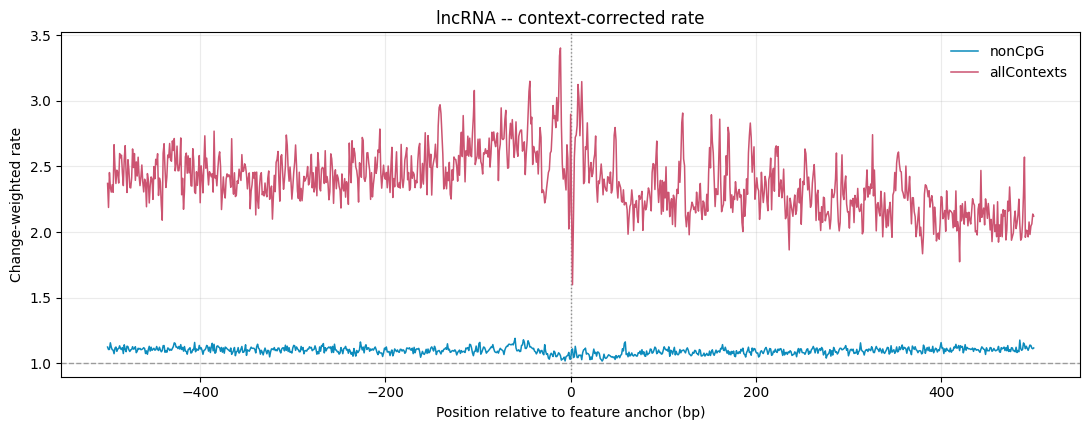

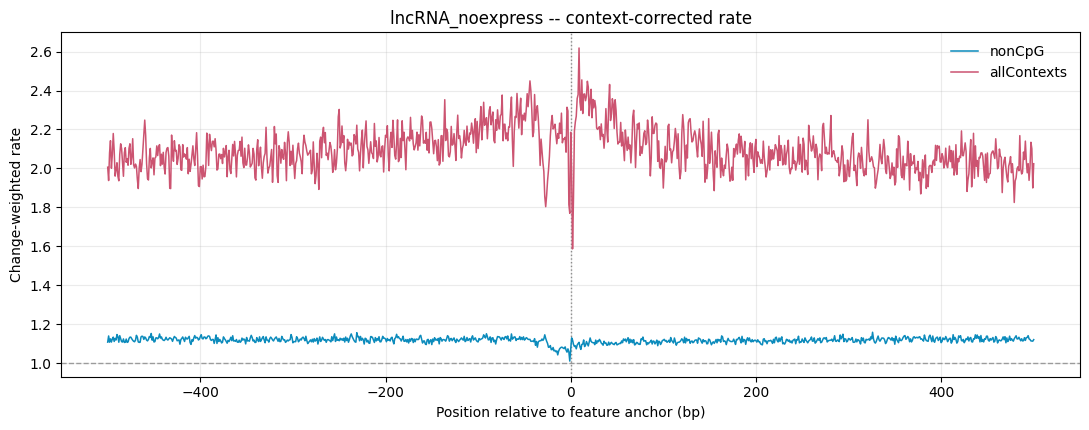

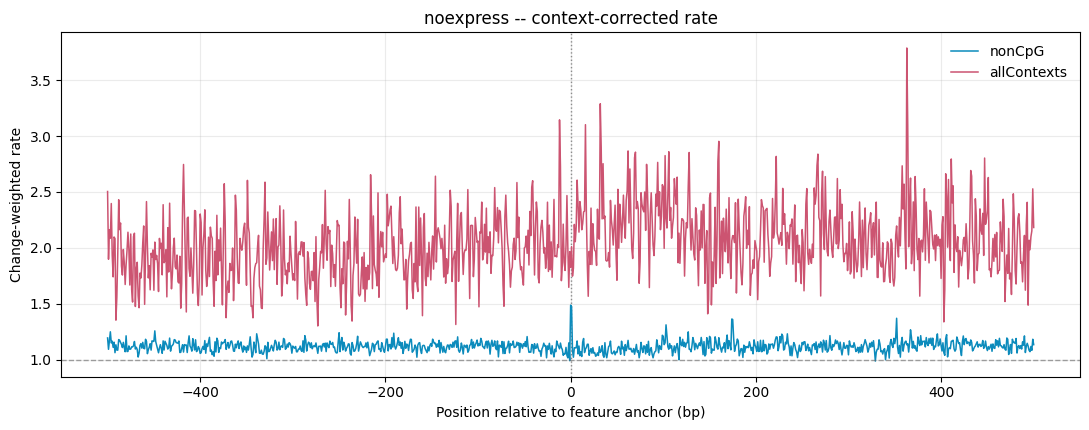

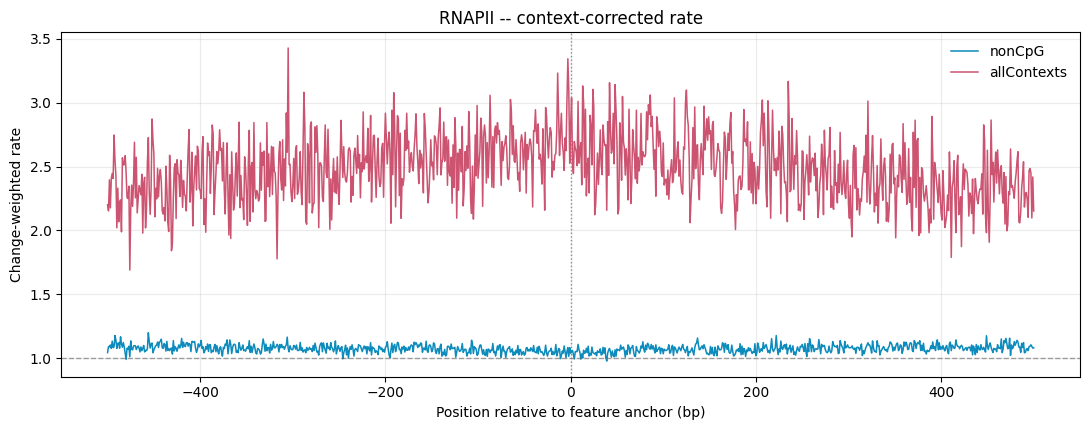

In [7]:
import json, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

CFG = json.load(open("/media/alexpalazzo1/ohta/Tina/TSS_hypermutation/Rare_SNP/Context_corrections/config.json"))
W = CFG["workdir"]

for name in CFG["regions"]:
    fig, ax = plt.subplots(figsize=(11, 4.4))
    for mode, spec in CFG["modes"].items():
        df = pd.read_csv(os.path.join(W, f"{name}_rates_{mode}.tsv"), sep="\t")
        ax.plot(df["Position"], df["Change_weighted_rate"], lw=1.1, color=spec["color"], label=mode)
    ax.axhline(1.0, color="0.4", ls="--", lw=1, alpha=0.6)
    ax.axvline(0, color="0.5", ls=":", lw=1, zorder=0)
    ax.set_title(f"{name} -- context-corrected rate")
    ax.set_xlabel("Position relative to feature anchor (bp)")
    ax.set_ylabel("Change-weighted rate")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(os.path.join(W, f"{name}_rate.png"), dpi=300, bbox_inches="tight")
    plt.show()